In [2]:
import numpy as np
import pandas as pd

In [16]:
db = pd.read_csv("train_transaction.csv")

In [17]:
db.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
db.shape

(8907, 394)

In [19]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8907 entries, 0 to 8906
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 26.8+ MB


In [20]:
db.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,8.907000e+03,8907.000000,8907.000000,8907.000000,8907.000000,8801.000000,8907.000000,8891.000000,8130.000000,8130.000000,...,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,2.991453e+06,0.026496,175655.754126,134.739067,9789.777254,349.467220,152.679578,200.405466,292.201845,87.007749,...,0.128571,44.082353,60.489076,50.455462,1.502521,12.420168,4.955462,13.731092,17.526891,14.978992
std,2.571374e+03,0.160614,48948.945272,221.852071,4775.490923,157.681157,9.938366,38.943175,103.487306,0.263989,...,0.531061,265.845111,291.406795,275.144056,10.884882,80.739496,44.335147,92.207002,109.541143,96.753111
min,2.987000e+06,0.000000,86400.000000,1.896000,1030.000000,100.000000,100.000000,100.000000,110.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.989226e+06,0.000000,144089.500000,45.000000,6351.000000,194.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.991453e+06,0.000000,165720.000000,75.000000,9500.000000,327.000000,150.000000,224.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.993680e+06,0.000000,228493.500000,141.000000,13741.500000,500.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.995906e+06,1.000000,260187.000000,3247.910000,18390.000000,600.000000,214.000000,237.000000,536.000000,96.000000,...,6.000000,6300.000000,6300.000000,6300.000000,150.000000,1300.000000,1300.000000,1500.000000,1630.000000,1500.000000


In [21]:
db.isnull().sum()

,0
TransactionID,0
isFraud,0
TransactionDT,0
TransactionAmt,0
ProductCD,0
...,...
V335,7717
V336,7717
V337,7717
V338,7717


In [22]:
db["isFraud"].value_counts()

,count
isFraud,
0,8671
1,236


In [23]:
db["isFraud"].value_counts(normalize=True) * 100

,proportion
isFraud,
0,97.350399
1,2.649601


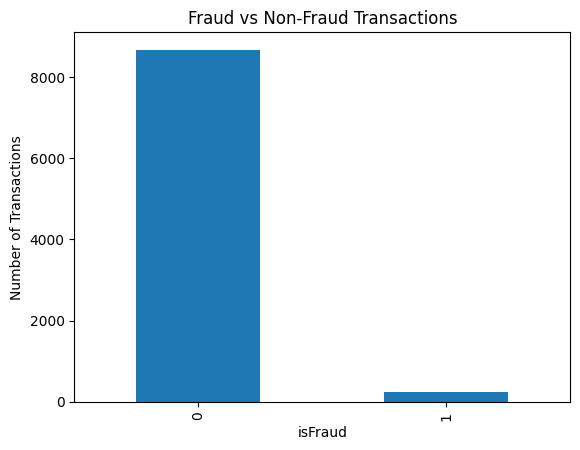

In [24]:
import matplotlib.pyplot as plt

db["isFraud"].value_counts().plot(kind="bar")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.show()

In [25]:
db["ProductCD"].value_counts()

,count
ProductCD,
W,6947
C,770
H,726
R,283
S,181


In [26]:
db.groupby("ProductCD")["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
ProductCD,,,
C,770,82,0.106494
H,726,7,0.009642
R,283,16,0.056537
S,181,10,0.055249
W,6947,121,0.017418


In [27]:
db["card4"].value_counts()

,count
card4,
visa,5508
mastercard,3221
american express,97
discover,81


In [28]:
db.groupby("card4")["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
card4,,,
american express,97,2,0.020619
discover,81,3,0.037037
mastercard,3221,108,0.033530
visa,5508,123,0.022331


In [29]:
db["card6"].value_counts()

,count
card6,
debit,7096
credit,1811


In [30]:
db.groupby("card6")["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
card6,,,
credit,1811,134,0.073992
debit,7096,102,0.014374


In [31]:
db.dtypes.value_counts()

,count
float64,376
object,14
int64,4


In [32]:
categorical_columns = db.select_dtypes(
    include=["object"]
).columns

print("Number of categorical columns:", len(categorical_columns))
print(categorical_columns.tolist())

Number of categorical columns: 14
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [33]:
db["TransactionID"].duplicated().sum()

np.int64(0)

In [34]:
identity = pd.read_csv("train_identity.csv")

In [35]:
identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [36]:
identity.shape

(144233, 41)

In [37]:
identity.columns

Index(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14',
       'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22',
       'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30',
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object')

In [38]:
identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [39]:
identity.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,144233.0,NaN,NaN,NaN,3236329.311288,178849.571186,2987004.0,3077142.0,3198818.0,3392923.0,3577534.0
id_01,144233.0,NaN,NaN,NaN,-10.170502,14.347949,-100.0,-10.0,-5.0,-5.0,0.0
id_02,140872.0,NaN,NaN,NaN,174716.584708,159651.816856,1.0,67992.0,125800.5,228749.0,999595.0
id_03,66324.0,NaN,NaN,NaN,0.060189,0.598231,-13.0,0.0,0.0,0.0,10.0
id_04,66324.0,NaN,NaN,NaN,-0.058938,0.701015,-28.0,0.0,0.0,0.0,0.0
id_05,136865.0,NaN,NaN,NaN,1.615585,5.249856,-72.0,0.0,0.0,1.0,52.0
id_06,136865.0,NaN,NaN,NaN,-6.69871,16.491104,-100.0,-6.0,0.0,0.0,0.0
id_07,5155.0,NaN,NaN,NaN,13.285354,11.384207,-46.0,5.0,14.0,22.0,61.0
id_08,5155.0,NaN,NaN,NaN,-38.600388,26.084899,-100.0,-48.0,-34.0,-23.0,0.0
id_09,74926.0,NaN,NaN,NaN,0.091023,0.983842,-36.0,0.0,0.0,0.0,25.0


In [40]:
identity.isnull().sum().sort_values(ascending=False)

,0
id_24,139486
id_25,139101
id_07,139078
id_08,139078
id_21,139074
id_26,139070
id_23,139064
id_27,139064
id_22,139064
id_18,99120


In [41]:
identity_missing = pd.DataFrame({
    "missing_count": identity.isnull().sum(),
    "missing_percent": identity.isnull().mean() * 100
})

identity_missing.sort_values(
    "missing_percent",
    ascending=False
).head(30)

,missing_count,missing_percent
id_24,139486,96.708798
id_25,139101,96.441868
id_07,139078,96.425922
id_08,139078,96.425922
id_21,139074,96.423149
id_26,139070,96.420375
id_23,139064,96.416215
id_27,139064,96.416215
id_22,139064,96.416215
id_18,99120,68.722137


In [42]:
identity.dtypes.value_counts()

,count
float64,23
object,17
int64,1


In [43]:
identity_categorical = identity.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:", len(identity_categorical))
print(identity_categorical.tolist())

Categorical columns: 17
['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [44]:
identity_cardinality = pd.DataFrame({
    "column": identity.columns,
    "unique_values": [
        identity[col].nunique(dropna=True)
        for col in identity.columns
    ]
})

identity_cardinality.sort_values(
    "unique_values",
    ascending=False
)

,column,unique_values
0,TransactionID,144233
2,id_02,115655
40,DeviceInfo,1786
19,id_19,522
21,id_21,490
20,id_20,394
11,id_11,365
25,id_25,341
33,id_33,260
31,id_31,130


In [45]:
identity["TransactionID"].duplicated().sum()

np.int64(0)

In [46]:
print("Transaction IDs in transaction data:", db["TransactionID"].nunique())
print("Transaction IDs in identity data:", identity["TransactionID"].nunique())

Transaction IDs in transaction data: 8907
Transaction IDs in identity data: 144233


In [47]:
common_ids = set(db["TransactionID"]).intersection(
    set(identity["TransactionID"])
)

print("Transactions:", len(db))
print("Identity records:", len(identity))
print("Matching transactions:", len(common_ids))

Transactions: 8907
Identity records: 144233
Matching transactions: 1842


In [48]:
print(
    "Identity coverage:",
    round(len(common_ids) / len(db) * 100, 2),
    "%"
)

Identity coverage: 20.68 %


In [49]:
for col in identity.columns:
    print(col)

TransactionID
id_01
id_02
id_03
id_04
id_05
id_06
id_07
id_08
id_09
id_10
id_11
id_12
id_13
id_14
id_15
id_16
id_17
id_18
id_19
id_20
id_21
id_22
id_23
id_24
id_25
id_26
id_27
id_28
id_29
id_30
id_31
id_32
id_33
id_34
id_35
id_36
id_37
id_38
DeviceType
DeviceInfo


In [50]:
print(db.shape)
print(db["TransactionID"].min())
print(db["TransactionID"].max())

(8907, 394)
2987000
2995906


In [51]:
print(identity.shape)
print(identity["TransactionID"].min())
print(identity["TransactionID"].max())

(144233, 41)
2987004
3577534


In [52]:
identity_analysis = db[["TransactionID", "isFraud"]].merge(
    identity,
    on="TransactionID",
    how="left"
)

print(identity_analysis.shape)

(8907, 42)


In [53]:
identity_analysis.head()

,TransactionID,isFraud,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [54]:
identity_analysis["has_identity"] = (
    identity_analysis["id_01"].notna()
).astype(int)

In [55]:
identity_analysis.groupby(
    "has_identity"
)["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
has_identity,,,
0,7065,128,0.018117
1,1842,108,0.058632


In [56]:
identity_analysis.groupby(
    "DeviceType"
)["isFraud"].agg(
    ["count", "sum", "mean"]
).sort_values(
    "mean",
    ascending=False
)

,count,sum,mean
DeviceType,,,
mobile,646,59,0.091331
desktop,1159,49,0.042278


In [57]:
identity_analysis.groupby(
    "id_31"
)["isFraud"].agg(
    ["count", "sum", "mean"]
).sort_values(
    "count",
    ascending=False
).head(20)

,count,sum,mean
id_31,,,
chrome 62.0,628,37,0.058917
mobile safari 11.0,255,13,0.050980
chrome 62.0 for android,143,23,0.160839
ie 11.0 for desktop,121,1,0.008264
safari generic,108,0,0.000000
firefox 57.0,89,7,0.078652
mobile safari 10.0,71,1,0.014085
edge 15.0,50,0,0.000000
mobile safari generic,45,4,0.088889


In [58]:
identity["DeviceInfo"].nunique()

1786

In [59]:
identity["DeviceInfo"].value_counts().head(20)

,count
DeviceInfo,
Windows,47722
iOS Device,19782
MacOS,12573
Trident/7.0,7440
rv:11.0,1901
rv:57.0,962
SM-J700M Build/MMB29K,549
SM-G610M Build/MMB29K,461
SM-G531H Build/LMY48B,410
